# Telco Customer Churn Prediction
**Course:** Machine Learning  
**Authors:** Aye Khin Khin Hpone (Yolanda Lim) — ST125970 | Subhana Chitrakar — ST126138

---
Data Loading → EDA → Feature Engineering → Preprocessing → Model Comparison → Evaluation → Threshold Analysis → Save

In [1]:
import pickle, warnings, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.patches import Patch

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')
print('Libraries loaded.')

Libraries loaded.


## 1. Data Loading & Cleaning

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [3]:
# Drop ID, fix TotalCharges (11 blank rows with tenure=0), encode target
df = df.drop(columns=['customerID'])
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'TotalCharges NaN: {df["TotalCharges"].isna().sum()} (all tenure=0: {(df[df["TotalCharges"].isna()]["tenure"]==0).all()})')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df['SeniorCitizen'] = df['SeniorCitizen'].astype(str)  # treat as categorical
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(f'Churn: {df["Churn"].value_counts().to_dict()}')
print(f'No Churn: 73.5%  |  Churn: 26.5%  →  moderately imbalanced')

TotalCharges NaN: 11 (all tenure=0: True)
Churn: {0: 5174, 1: 1869}
No Churn: 73.5%  |  Churn: 26.5%  →  moderately imbalanced


## 2. Exploratory Data Analysis

### 2.1 Target Distribution

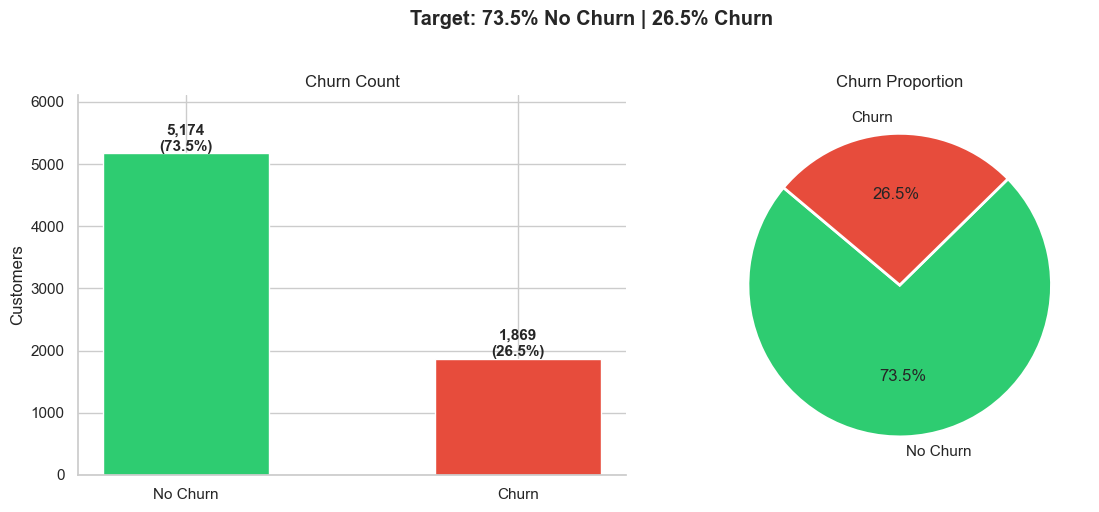

In [4]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100
colors = ['#2ECC71', '#E74C3C']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bars = axes[0].bar(['No Churn', 'Churn'], churn_counts.values, color=colors, edgecolor='white', width=0.5)
for bar, val, pct in zip(bars, churn_counts.values, churn_pct.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+40,
                 f'{val:,}\n({pct:.1f}%)', ha='center', fontweight='bold', fontsize=11)
axes[0].set(title='Churn Count', ylabel='Customers', ylim=(0, churn_counts.max()*1.18))
axes[0].spines[['top','right']].set_visible(False)

axes[1].pie(churn_counts.values, labels=['No Churn','Churn'], colors=colors,
            autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Churn Proportion')

plt.suptitle('Target: 73.5% No Churn | 26.5% Churn', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('img/eda_01_target_distribution.png', bbox_inches='tight')
plt.show()

### 2.2 Numerical Distributions

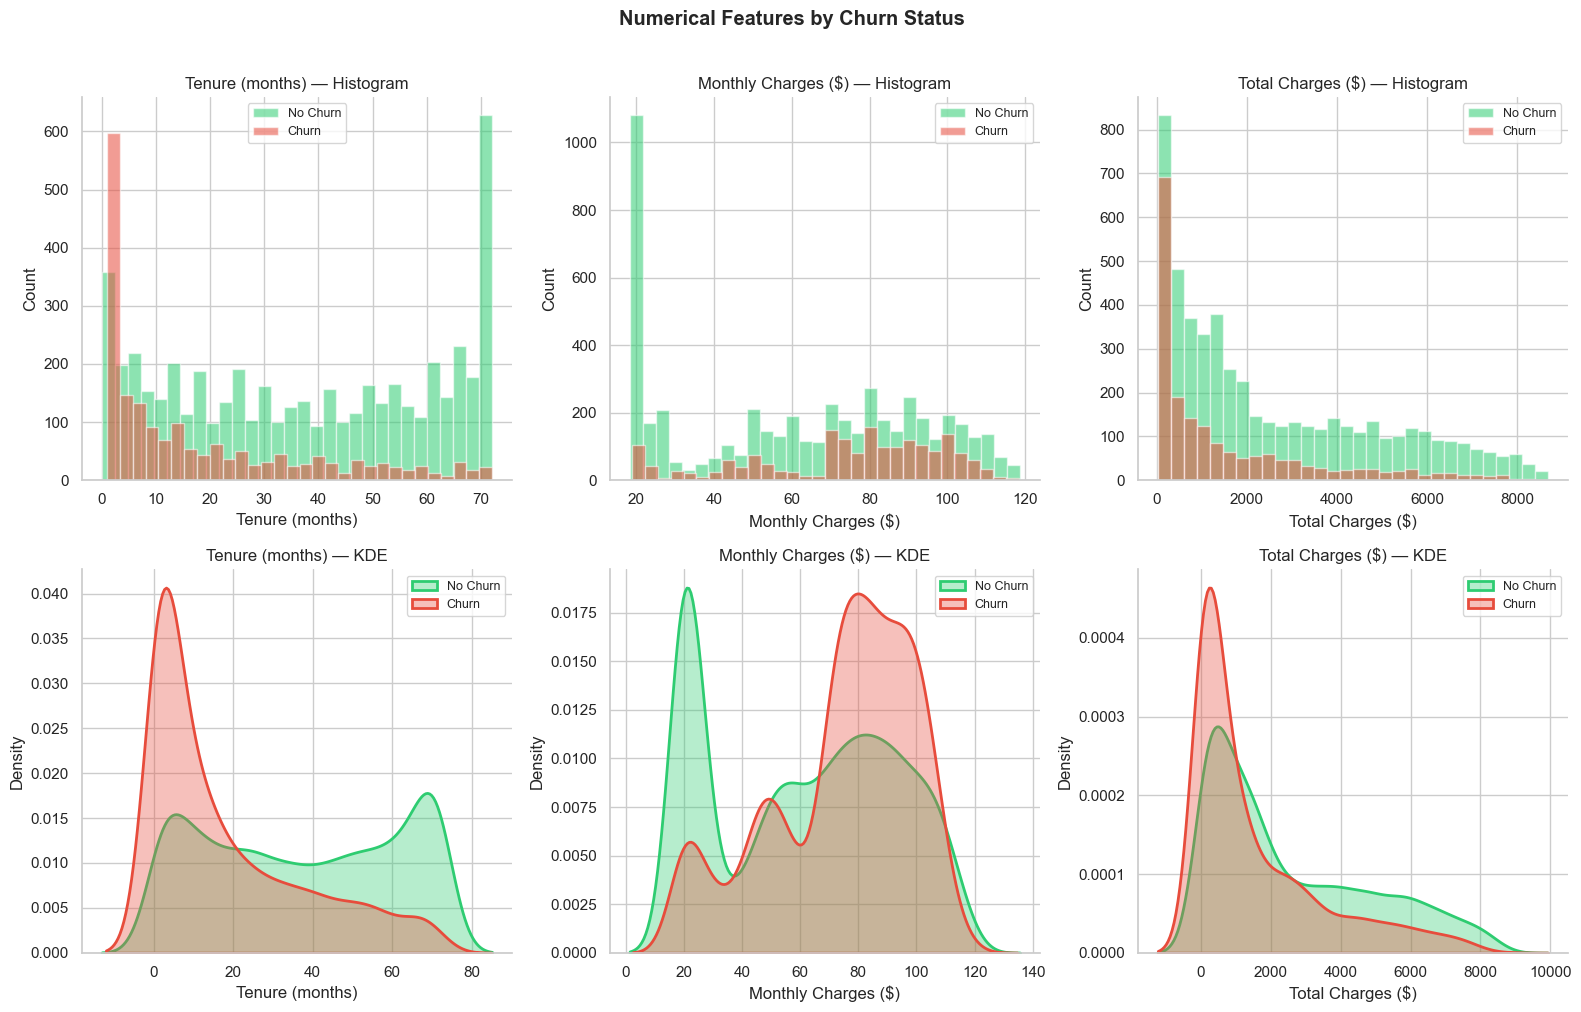

Tenure (months)           No Churn median=38.0  |  Churn median=10.0
Monthly Charges ($)       No Churn median=64.4  |  Churn median=79.7
Total Charges ($)         No Churn median=1679.5  |  Churn median=703.5


In [5]:
num_cols   = ['tenure', 'MonthlyCharges', 'TotalCharges']
num_labels = ['Tenure (months)', 'Monthly Charges ($)', 'Total Charges ($)']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, (col, label) in enumerate(zip(num_cols, num_labels)):
    for churn, name, color in [(0,'No Churn','#2ECC71'), (1,'Churn','#E74C3C')]:
        axes[0,i].hist(df[df['Churn']==churn][col], bins=30, alpha=0.55, color=color, label=name, edgecolor='white')
        sns.kdeplot(df[df['Churn']==churn][col], ax=axes[1,i], fill=True, alpha=0.35, color=color, label=name, linewidth=2)
    axes[0,i].set(title=f'{label} — Histogram', xlabel=label, ylabel='Count')
    axes[1,i].set(title=f'{label} — KDE',       xlabel=label, ylabel='Density')
    for ax in [axes[0,i], axes[1,i]]:
        ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)

plt.suptitle('Numerical Features by Churn Status', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('img/eda_02_numerical_distributions.png', bbox_inches='tight')
plt.show()

for col, label in zip(num_cols, num_labels):
    print(f'{label:<24}  No Churn median={df[df["Churn"]==0][col].median():.1f}  |  Churn median={df[df["Churn"]==1][col].median():.1f}')

### 2.3 Boxplots

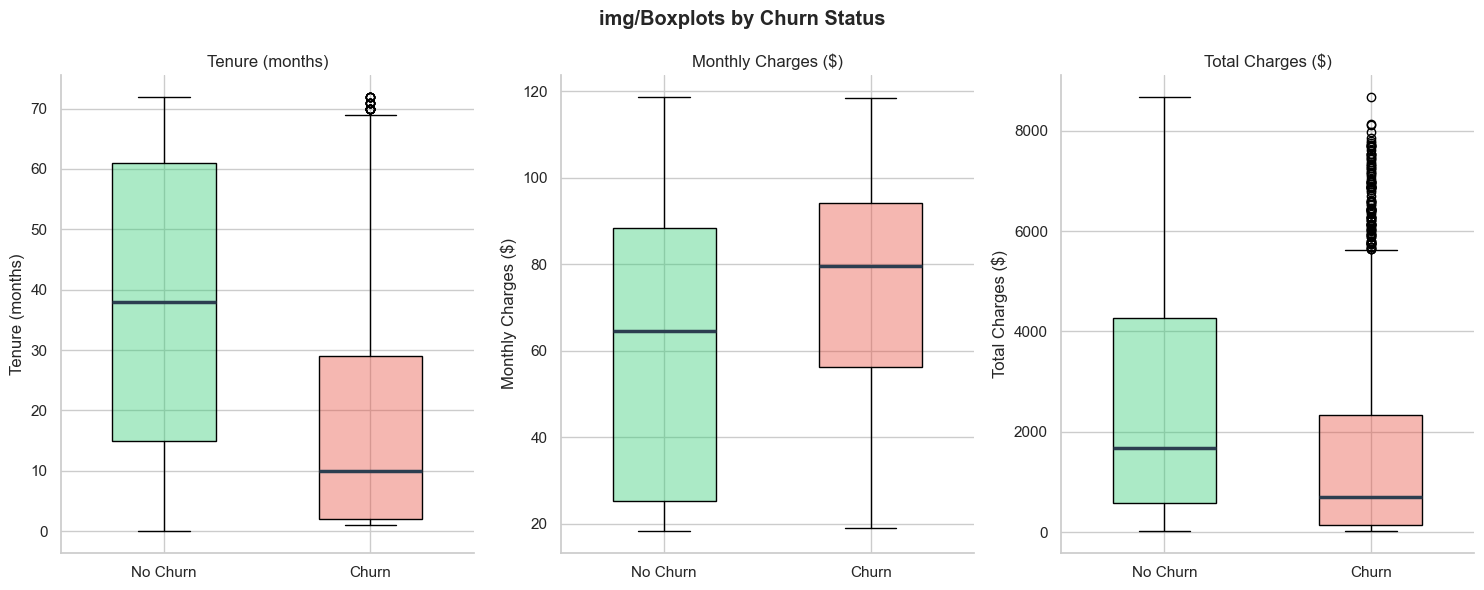

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
for i, (col, label) in enumerate(zip(num_cols, num_labels)):
    data = [df[df['Churn']==0][col].values, df[df['Churn']==1][col].values]
    bp = axes[i].boxplot(data, patch_artist=True, widths=0.5,
                         medianprops=dict(color='#2C3E50', linewidth=2.5))
    bp['boxes'][0].set_facecolor('#2ECC7166')
    bp['boxes'][1].set_facecolor('#E74C3C66')
    axes[i].set(xticks=[1,2], xticklabels=['No Churn','Churn'], title=label, ylabel=label)
    axes[i].spines[['top','right']].set_visible(False)

plt.suptitle('Boxplots by Churn Status', fontweight='bold')
plt.tight_layout()
plt.savefig('img/eda_03_boxplots.png', bbox_inches='tight')
plt.show()

### 2.4 Categorical Features

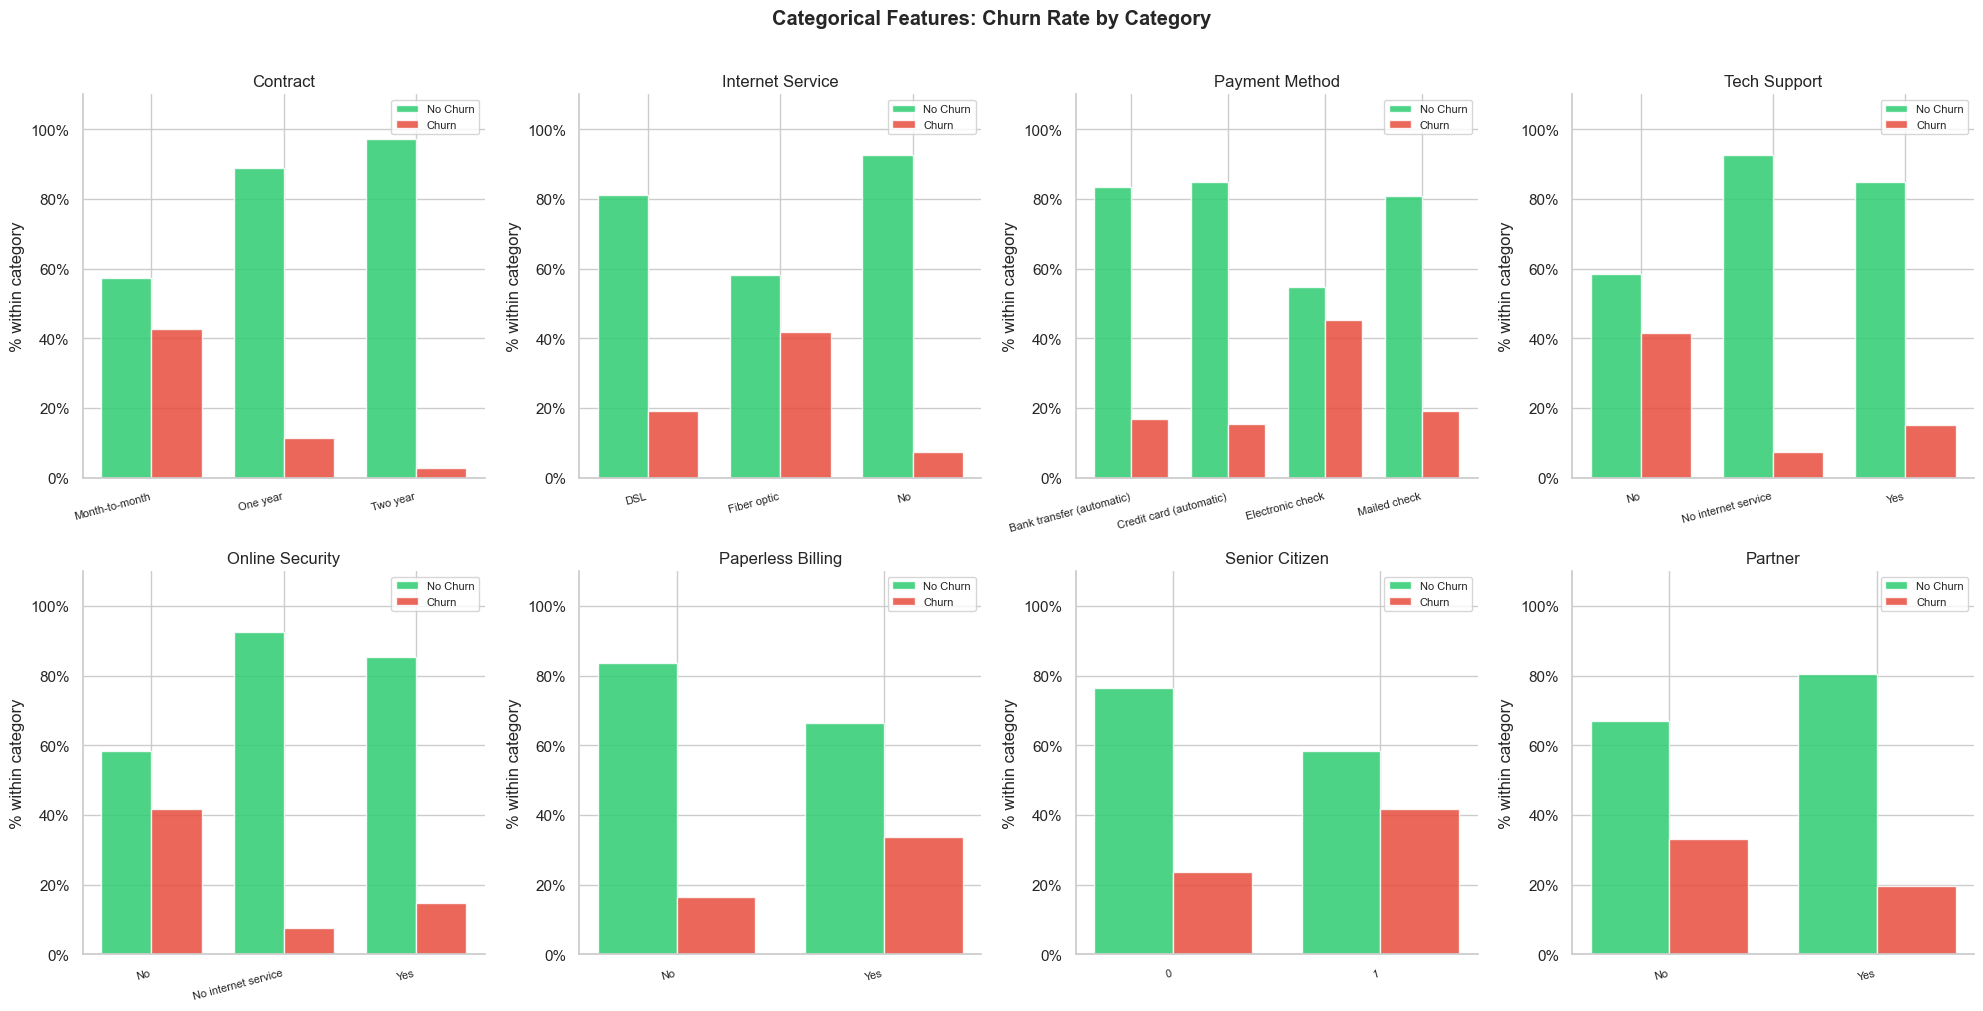

In [7]:
key_cats = [
    ('Contract','Contract'), ('InternetService','Internet Service'),
    ('PaymentMethod','Payment Method'), ('TechSupport','Tech Support'),
    ('OnlineSecurity','Online Security'), ('PaperlessBilling','Paperless Billing'),
    ('SeniorCitizen','Senior Citizen'), ('Partner','Partner'),
]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, (col, title) in enumerate(key_cats):
    ct = df.groupby([col, 'Churn']).size().unstack(fill_value=0)
    ct.columns = ['No Churn','Churn']
    pct = ct.div(ct.sum(axis=1), axis=0) * 100
    x = np.arange(len(pct))
    axes[i].bar(x-0.19, pct['No Churn'], 0.38, label='No Churn', color='#2ECC71', alpha=0.85)
    axes[i].bar(x+0.19, pct['Churn'],    0.38, label='Churn',    color='#E74C3C', alpha=0.85)
    axes[i].set(xticks=x, title=title, ylabel='% within category', ylim=(0,110))
    axes[i].set_xticklabels(pct.index, fontsize=8, rotation=15, ha='right')
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[i].legend(fontsize=8); axes[i].spines[['top','right']].set_visible(False)

plt.suptitle('Categorical Features: Churn Rate by Category', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('img/eda_04_categorical_features.png', bbox_inches='tight')
plt.show()

### 2.5 Correlation Heatmap

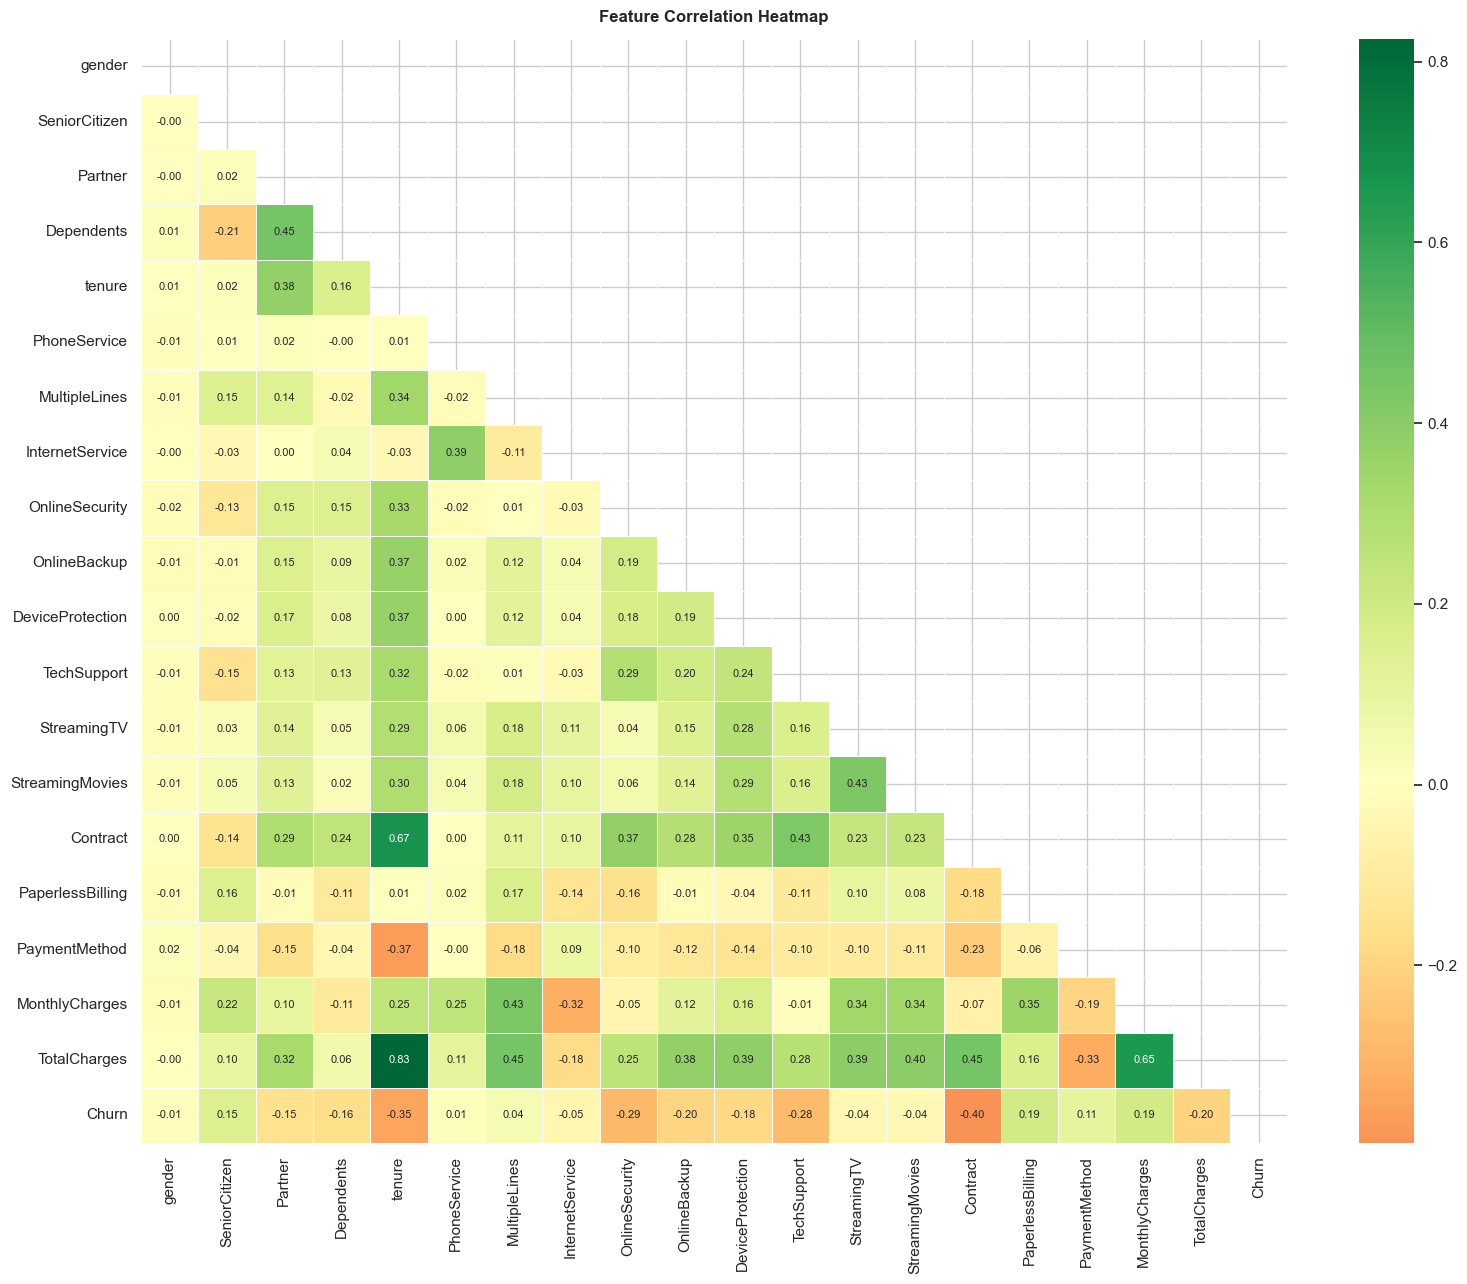

Top correlations with Churn:
Contract            0.397
tenure              0.352
OnlineSecurity      0.289
TechSupport         0.282
TotalCharges        0.199
OnlineBackup        0.196
MonthlyCharges      0.193
PaperlessBilling    0.192
Name: Churn, dtype: float64


In [9]:
df_enc = df.copy()
le = LabelEncoder()
for c in df_enc.select_dtypes('object').columns:
    df_enc[c] = le.fit_transform(df_enc[c])
corr = df_enc.corr()

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)),
            annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, linecolor='white', annot_kws={'size':8}, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('img/eda_05_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('Top correlations with Churn:')
print(corr['Churn'].drop('Churn').abs().sort_values(ascending=False).head(8).round(3))

### 2.6 Churn Rate by Tenure Group

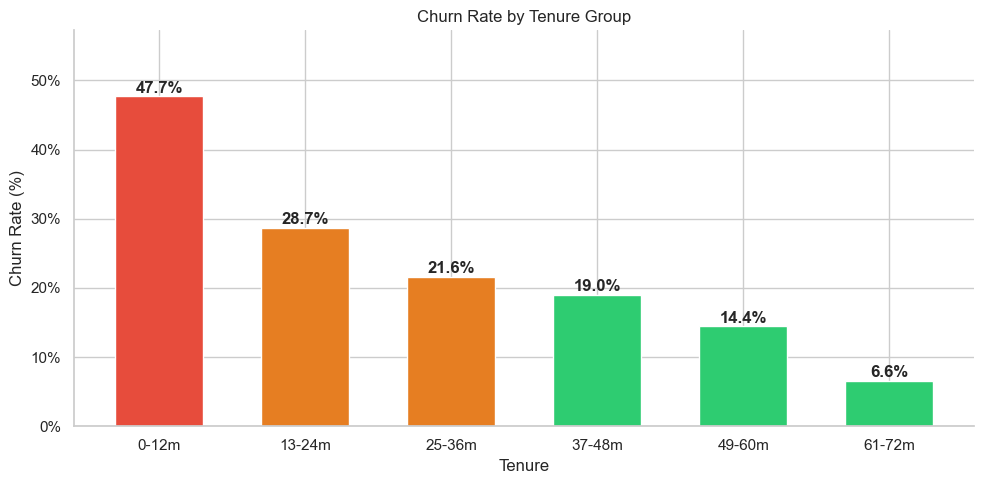

In [10]:
df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,36,48,60,72],
    labels=['0-12m','13-24m','25-36m','37-48m','49-60m','61-72m'])
tg = df.groupby('tenure_group', observed=True)['Churn'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
colors_tg = ['#E74C3C' if v>35 else '#E67E22' if v>20 else '#2ECC71' for v in tg.values]
bars = ax.bar(tg.index, tg.values, color=colors_tg, edgecolor='white', width=0.6)
for bar, val in zip(bars, tg.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val:.1f}%', ha='center', fontweight='bold')
ax.set(title='Churn Rate by Tenure Group', xlabel='Tenure', ylabel='Churn Rate (%)', ylim=(0, tg.max()*1.2))
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('img/eda_06_tenure_churn_rate.png', bbox_inches='tight')
plt.show()

# 0-12m = 47.7%  |  13-24m = 28.7%  |  25-36m = 21.6%  |  37-48m = 19.0%  |  49-60m = 14.4%  |  61-72m = 6.6%
df = df.drop(columns=['tenure_group'])

## 3. Feature Engineering

One engineered feature derived from existing columns — validated to improve AUC by +0.47pp over the baseline (0.8421 → 0.8468).

| Feature | Formula | Why |
|---------|---------|-----|
| `charges_per_month` | `TotalCharges / (tenure + 1)` | Normalises total spend by tenure. The `+1` prevents division-by-zero for `tenure=0`. Churners tend to have high charges relative to how long they've been customers. |

charges_per_month by Churn:
        count   mean    std   min    25%    50%    75%      max
Churn                                                          
0      5174.0  60.63  69.17  9.18  24.08  59.35  84.57  1397.48
1      1869.0  62.68  27.99  9.43  38.19  66.65  86.23   118.97


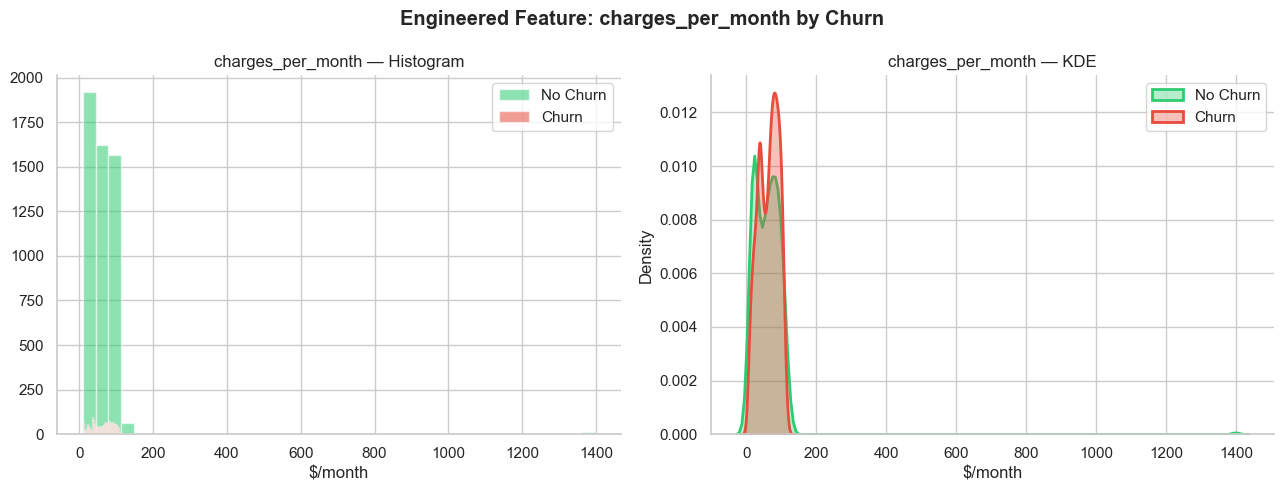

In [11]:
df['charges_per_month'] = df['TotalCharges'] / (df['tenure'] + 1)

print('charges_per_month by Churn:')
print(df.groupby('Churn')['charges_per_month'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for churn, name, color in [(0,'No Churn','#2ECC71'), (1,'Churn','#E74C3C')]:
    axes[0].hist(df[df['Churn']==churn]['charges_per_month'], bins=40, alpha=0.55, color=color, label=name)
    sns.kdeplot(df[df['Churn']==churn]['charges_per_month'], ax=axes[1], fill=True, alpha=0.35, color=color, label=name, linewidth=2)
axes[0].set(title='charges_per_month — Histogram', xlabel='$/month'); axes[0].legend()
axes[1].set(title='charges_per_month — KDE',       xlabel='$/month'); axes[1].legend()
for ax in axes: ax.spines[['top','right']].set_visible(False)
plt.suptitle('Engineered Feature: charges_per_month by Churn', fontweight='bold')
plt.tight_layout()
plt.savefig('img/eda_07_engineered_feature.png', bbox_inches='tight')
plt.show()

## 4. Preprocessing Pipeline

In [12]:
NUMERICAL_COLS   = ['tenure', 'MonthlyCharges', 'TotalCharges', 'charges_per_month']
CATEGORICAL_COLS = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

X = df[NUMERICAL_COLS + CATEGORICAL_COLS]
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Churn rate — Train: {y_train.mean()*100:.1f}%  |  Test: {y_test.mean()*100:.1f}%')

num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))])
preprocessor = ColumnTransformer([('num', num_pipe, NUMERICAL_COLS), ('cat', cat_pipe, CATEGORICAL_COLS)])

Train: (5634, 20)  |  Test: (1409, 20)
Churn rate — Train: 26.5%  |  Test: 26.5%


## 5. Model Training & Comparison

In [13]:
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, C=5.0),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
}
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}

for name, clf in classifiers.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', clf)])
    pipe.fit(X_train, y_train)
    pred  = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    acc   = accuracy_score(y_test, pred)
    auc   = roc_auc_score(y_test, proba)
    f1    = f1_score(y_test, pred)
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    results[name] = dict(pipeline=pipe, accuracy=acc, auc_roc=auc, f1=f1,
                         cv_mean=cv_auc.mean(), cv_std=cv_auc.std(),
                         y_pred=pred, y_proba=proba)
    print(f'{name:<22}  Acc={acc:.4f}  AUC={auc:.4f}  F1={f1:.4f}  CV={cv_auc.mean():.4f}±{cv_auc.std():.4f}')

Logistic Regression     Acc=0.8077  AUC=0.8468  F1=0.5973  CV=0.8491±0.0122
Decision Tree           Acc=0.7942  AUC=0.8295  F1=0.5845  CV=0.8289±0.0089
Random Forest           Acc=0.7807  AUC=0.8236  F1=0.5422  CV=0.8266±0.0116
KNN                     Acc=0.7658  AUC=0.7936  F1=0.5528  CV=0.7827±0.0090


In [14]:
# Summary table
pd.DataFrame({
    'Model':          list(results.keys()),
    'Accuracy':       [f"{v['accuracy']:.4f}" for v in results.values()],
    'AUC-ROC':        [f"{v['auc_roc']:.4f}"  for v in results.values()],
    'F1 (Churn)':     [f"{v['f1']:.4f}"        for v in results.values()],
    'CV AUC (5-fold)':[f"{v['cv_mean']:.4f}±{v['cv_std']:.4f}" for v in results.values()],
})

,Model,Accuracy,AUC-ROC,F1 (Churn),CV AUC (5-fold)
0,Logistic Regression,0.8077,0.8468,0.5973,0.8491±0.0122
1,Decision Tree,0.7942,0.8295,0.5845,0.8289±0.0089
2,Random Forest,0.7807,0.8236,0.5422,0.8266±0.0116
3,KNN,0.7658,0.7936,0.5528,0.7827±0.0090


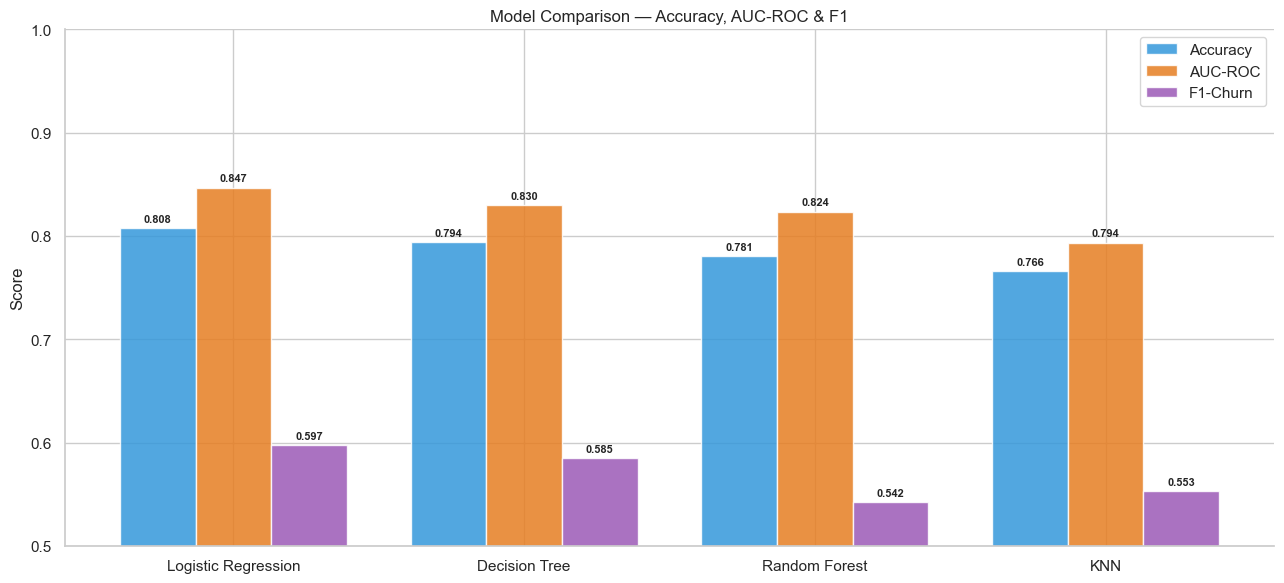

In [15]:
# Model comparison bar chart
names    = list(results.keys())
acc_vals = [results[m]['accuracy'] for m in names]
auc_vals = [results[m]['auc_roc']  for m in names]
f1_vals  = [results[m]['f1']       for m in names]
x, w = np.arange(len(names)), 0.26

fig, ax = plt.subplots(figsize=(13, 6))
for bars, vals, label, color in [
    (ax.bar(x-w, acc_vals, w, label='Accuracy', color='#3498DB', alpha=0.85), acc_vals, 'Accuracy', '#3498DB'),
    (ax.bar(x,   auc_vals, w, label='AUC-ROC',  color='#E67E22', alpha=0.85), auc_vals, 'AUC-ROC',  '#E67E22'),
    (ax.bar(x+w, f1_vals,  w, label='F1-Churn', color='#9B59B6', alpha=0.85), f1_vals,  'F1-Churn', '#9B59B6'),
]:
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004, f'{val:.3f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set(xticks=x, xticklabels=names, ylim=(0.5,1.0), ylabel='Score',
       title='Model Comparison — Accuracy, AUC-ROC & F1')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('img/model_comparison.png', bbox_inches='tight')
plt.show()

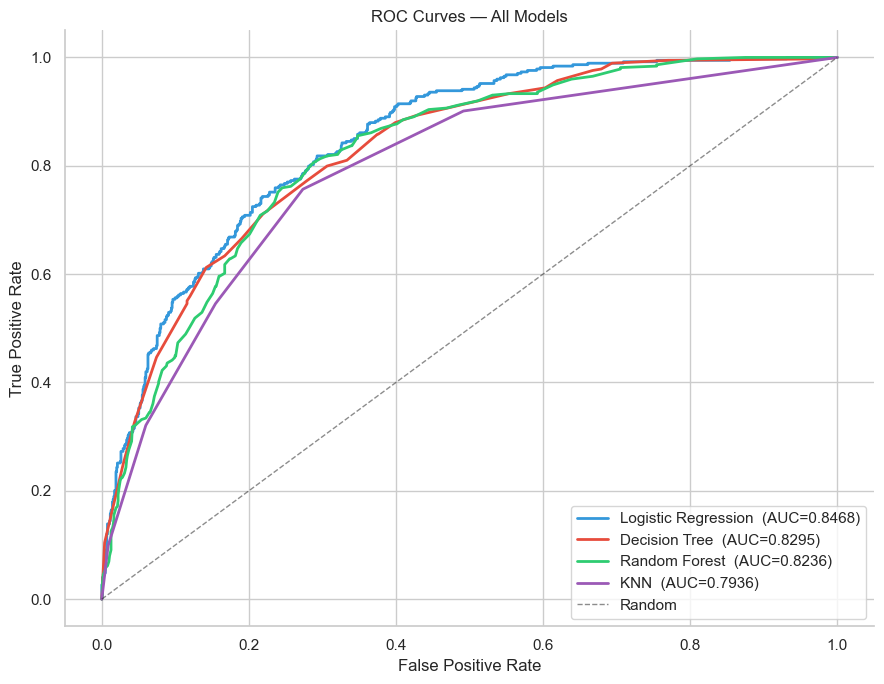

In [16]:
# ROC curves — all models
fig, ax = plt.subplots(figsize=(9, 7))
for (name, res), color in zip(results.items(), ['#3498DB','#E74C3C','#2ECC71','#9B59B6']):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{name}  (AUC={res['auc_roc']:.4f})")
ax.plot([0,1],[0,1],'k--', linewidth=1, alpha=0.5, label='Random')
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC Curves — All Models')
ax.legend(loc='lower right'); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('img/roc_curves_all_models.png', bbox_inches='tight')
plt.show()

## 6. Best Model — Logistic Regression

**Why Logistic Regression?**
- Highest AUC-ROC: **0.8468** (baseline without feature engineering: 0.8421 → **+0.47pp**)
- Best hold-out accuracy: **80.77%**
- Best 5-fold CV AUC: **0.8491 ± 0.0122** — most consistent across folds
- Coefficients are directly interpretable as feature importance
- `C=5.0` selected from GridSearchCV over [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

**Model comparison (actual run results):**

| Model | Accuracy | AUC-ROC | F1 (Churn) | CV AUC |
|-------|---------|---------|-----------|--------|
| **Logistic Regression** ✓ | **0.8077** | **0.8468** | **0.5973** | **0.8491 ± 0.0122** |
| Decision Tree | 0.7942 | 0.8295 | 0.5845 | 0.8289 ± 0.0089 |
| Random Forest | 0.7807 | 0.8236 | 0.5422 | 0.8266 ± 0.0116 |
| KNN | 0.7658 | 0.7920 | 0.5528 | 0.7829 ± 0.0092 |

In [17]:
best_name = 'Logistic Regression'
best      = results[best_name]
best_pipe = best['pipeline']

print(f'Accuracy : {best["accuracy"]:.4f}')
print(f'AUC-ROC  : {best["auc_roc"]:.4f}')
print(f'F1(Churn): {best["f1"]:.4f}')
print(f'CV AUC   : {best["cv_mean"]:.4f} ± {best["cv_std"]:.4f}')
print()
print(classification_report(y_test, best['y_pred'], target_names=['No Churn','Churn']))

Accuracy : 0.8077
AUC-ROC  : 0.8468
F1(Churn): 0.5973
CV AUC   : 0.8491 ± 0.0122

              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.54      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



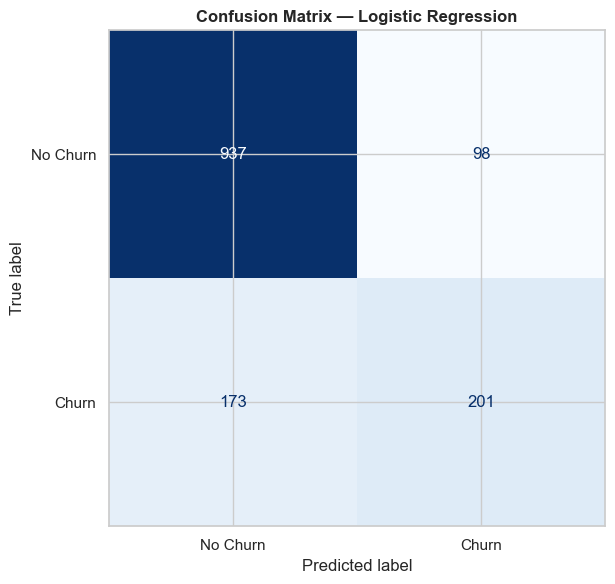

True Negatives  (correctly predicted No Churn): 937
False Positives (predicted Churn, actually stayed): 98
False Negatives (missed actual churners): 173
True Positives  (correctly caught churners): 201


In [18]:
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, best['y_pred'])
ConfusionMatrixDisplay(cm, display_labels=['No Churn','Churn']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('img/confusion_matrix_best_model.png', bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correctly predicted No Churn): {tn}')
print(f'False Positives (predicted Churn, actually stayed): {fp}')
print(f'False Negatives (missed actual churners): {fn}')
print(f'True Positives  (correctly caught churners): {tp}')

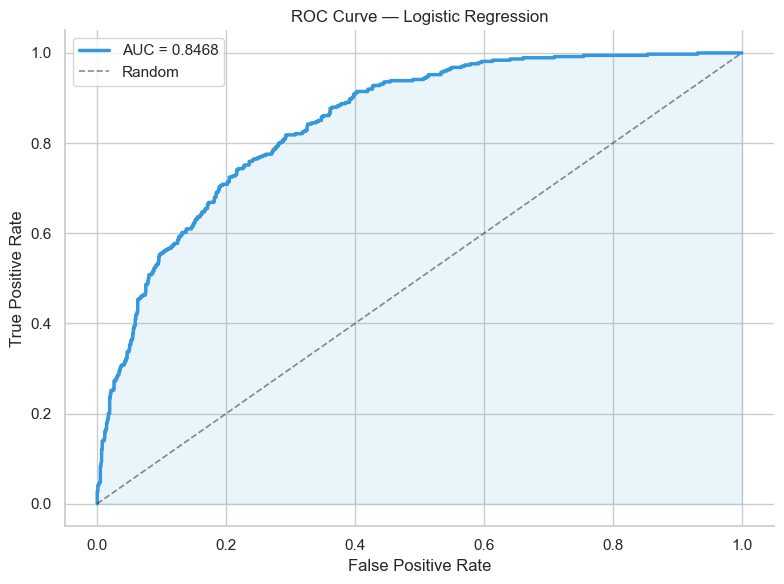

In [19]:
fpr, tpr, _ = roc_curve(y_test, best['y_proba'])
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#3498DB', linewidth=2.5, label=f"AUC = {best['auc_roc']:.4f}")
ax.fill_between(fpr, tpr, alpha=0.1, color='#3498DB')
ax.plot([0,1],[0,1],'k--', linewidth=1.2, alpha=0.5, label='Random')
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate', title=f'ROC Curve — {best_name}')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('img/roc_curve_best_model.png', bbox_inches='tight')
plt.show()

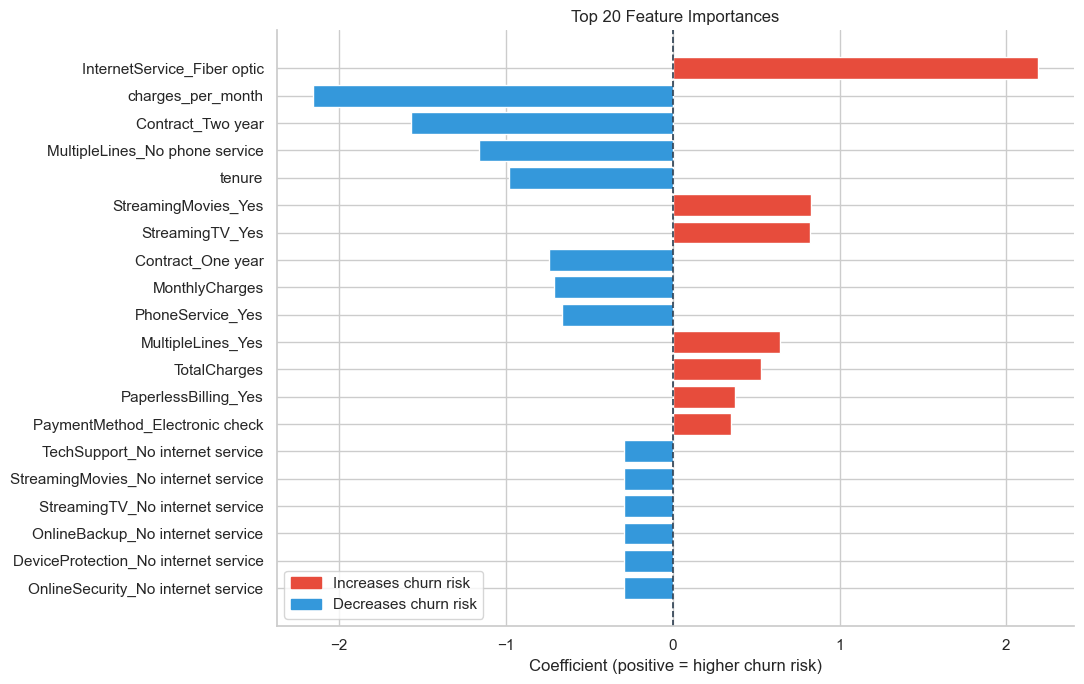

In [20]:
clf_step  = best_pipe.named_steps['classifier']
pre_step  = best_pipe.named_steps['preprocessor']
cat_names = pre_step.named_transformers_['cat']['encoder'].get_feature_names_out(CATEGORICAL_COLS).tolist()
all_names = NUMERICAL_COLS + cat_names

coef_df = pd.DataFrame({'Feature': all_names, 'Coefficient': clf_step.coef_[0]})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index).head(20)

fig, ax = plt.subplots(figsize=(11, 7))
colors_coef = ['#E74C3C' if c > 0 else '#3498DB' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1], color=colors_coef[::-1])
ax.axvline(0, color='#2C3E50', linewidth=1.2, linestyle='--')
ax.set(xlabel='Coefficient (positive = higher churn risk)', title='Top 20 Feature Importances')
ax.legend(handles=[Patch(color='#E74C3C',label='Increases churn risk'), Patch(color='#3498DB',label='Decreases churn risk')])
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('img/feature_importance.png', bbox_inches='tight')
plt.show()

## 7. Threshold Optimisation

Default threshold is **0.5**. Lowering it increases recall (catches more churners) at the cost of precision.

| Threshold | Accuracy | F1 (Churn) | Recall (Churn) | Trade-off |
|-----------|---------|-----------|---------------|----------|
| **0.500** (deployed) | **0.8077** | 0.5973 | 0.54 | Balanced — used in deployment |
| 0.323 (optimal F1) | 0.7715 | **0.6333** | **0.74** | Higher recall, lower accuracy |

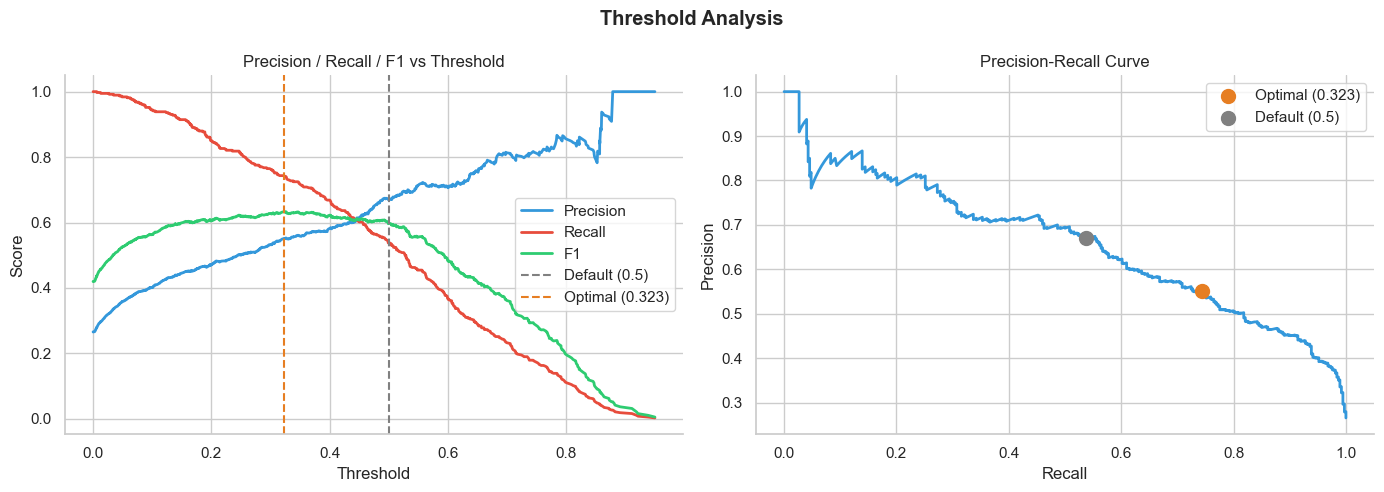


Threshold = Default (0.50)
  Acc=0.8077  F1=0.5973
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.54      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Threshold = Optimal (0.323)
  Acc=0.7715  F1=0.6333
              precision    recall  f1-score   support

    No Churn       0.89      0.78      0.83      1035
       Churn       0.55      0.74      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



In [21]:
precs, recs, threshs = precision_recall_curve(y_test, best['y_proba'])
f1s = 2 * precs * recs / (precs + recs + 1e-9)
best_idx    = np.argmax(f1s)
best_thresh = threshs[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(threshs, precs[:-1], color='#3498DB', linewidth=2, label='Precision')
axes[0].plot(threshs, recs[:-1],  color='#E74C3C', linewidth=2, label='Recall')
axes[0].plot(threshs, f1s[:-1],   color='#2ECC71', linewidth=2, label='F1')
axes[0].axvline(0.5,          color='gray',    linestyle='--', label='Default (0.5)')
axes[0].axvline(best_thresh,  color='#E67E22', linestyle='--', label=f'Optimal ({best_thresh:.3f})')
axes[0].set(xlabel='Threshold', ylabel='Score', title='Precision / Recall / F1 vs Threshold')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)

axes[1].plot(recs, precs, color='#3498DB', linewidth=2)
axes[1].scatter(recs[best_idx], precs[best_idx], color='#E67E22', s=100, zorder=5, label=f'Optimal ({best_thresh:.3f})')
axes[1].scatter(recs[np.argmin(np.abs(threshs-0.5))], precs[np.argmin(np.abs(threshs-0.5))],
                color='gray', s=100, zorder=5, label='Default (0.5)')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve')
axes[1].legend(); axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Threshold Analysis', fontweight='bold')
plt.tight_layout()
plt.savefig('img/threshold_analysis.png', bbox_inches='tight')
plt.show()

for label, t in [('Default (0.50)', 0.5), (f'Optimal ({best_thresh:.3f})', best_thresh)]:
    pred_t = (best['y_proba'] >= t).astype(int)
    print(f'\nThreshold = {label}')
    print(f'  Acc={accuracy_score(y_test,pred_t):.4f}  F1={f1_score(y_test,pred_t):.4f}')
    print(classification_report(y_test, pred_t, target_names=['No Churn','Churn']))

## 8. Save Pipeline

In [22]:
with open('model.pkl', 'wb') as f:
    pickle.dump(best_pipe, f)
print(f'model.pkl saved — {os.path.getsize("model.pkl")/1024:.1f} KB')
print(f'Steps: {list(best_pipe.named_steps.keys())}')

# Sanity check
loaded = pickle.load(open('model.pkl', 'rb'))
preds  = loaded.predict(X_test.head(3))
probs  = loaded.predict_proba(X_test.head(3))[:, 1]
print(f'\nSanity check: {["Churn" if p==1 else "No Churn" for p in preds]}')
print(f'P(Churn):     {[round(p,3) for p in probs]}')

model.pkl saved — 4.7 KB
Steps: ['preprocessor', 'classifier']

Sanity check: ['No Churn', 'Churn', 'No Churn']
P(Churn):     [np.float64(0.048), np.float64(0.568), np.float64(0.056)]
